# 3. Модели стационарных ВР (1): расширенный конспект + практика

Этот ноутбук переработан в формате мини-учебника:

- четкие формулы в LaTeX,
- интуитивные пояснения рядом с формулами,
- симуляции на сгенерированных данных,
- примеры на **двух** реальных рядах.

Структура:
1. Стационарность и разложение Вольда
2. MA(q): свойства, ACF/PACF, обратимость
3. AR(p): свойства, условия стационарности, Yule-Walker
4. ARMA(p,q): объединение механизмов и условия
5. Прогнозирование в AR/MA/ARMA
6. Реальные данные: `sunspots` и `nile`
7. Мини-итог + вопросы для самопроверки


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Стационарность: строго и интуитивно

Слабая (ковариационная) стационарность:

$$
\begin{aligned}
\mathbb{E}(Y_t) &= \mu = const, \\n
Var(Y_t) &= \sigma^2 = const, \\n
Cov(Y_t, Y_{t-k}) &= \gamma_k.
\end{aligned}
$$

Интуиция:
- средний уровень не дрейфует,
- разброс не «раздувается» со временем,
- зависимость определяется лагом $k$, а не календарной датой.

Разложение Вольда для недетерминированного стационарного процесса:

$$
Y_t = \mu + \sum_{j=0}^{\infty} \psi_j \varepsilon_{t-j}, \quad \varepsilon_t \sim WN(0,\sigma^2), \quad \sum_{j=0}^{\infty} \psi_j^2 < \infty.
$$

Интуиция Вольда: любой стационарный процесс можно рассматривать как линейный фильтр белого шума.


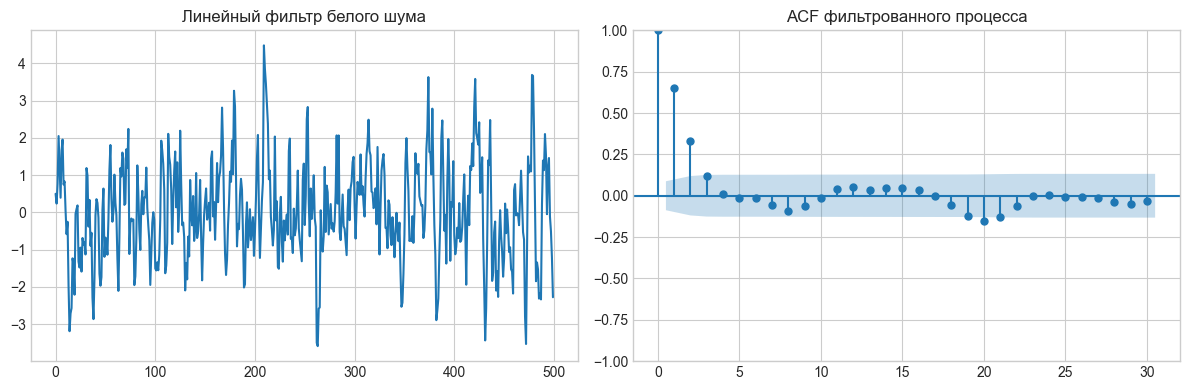

In [43]:
# Иллюстрация разложения Вольда: усеченный линейный фильтр (MA(infinity) в приближении)
T = 500
eps = np.random.normal(0, 1, T)
psi = np.array([1.0, 0.75, 0.45, 0.2, 0.1])

y = np.zeros(T)
for t in range(T):
    for j, coef in enumerate(psi):
        if t - j >= 0:
            y[t] += coef * eps[t - j]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(y, color='tab:blue')
axes[0].set_title('Линейный фильтр белого шума')
plot_acf(y, lags=30, ax=axes[1])
axes[1].set_title('ACF фильтрованного процесса')
plt.tight_layout()
plt.show()

Промежуточный вывод: стационарный ряд может быть полностью случайным по природе, но иметь устойчивую структуру автозависимости.

## 2. MA(q): модель скользящего среднего

### 2.1 Формула и смысл

$$
Y_t = \\theta_0 + \\varepsilon_t + \\theta_1 \\varepsilon_{t-1} + \\dots + \\theta_q \\varepsilon_{t-q}, \\quad \\varepsilon_t \\sim WN(0,\\sigma^2).
$$

Интуиция:
- в $Y_t$ нет прямой зависимости от $Y_{t-1}$,
- но есть зависимость от текущего и прошлых шоков,
- память у MA(q) конечная: глубина памяти определяется $q$.

Ключевой факт: **MA(q) стационарен при любых значениях коэффициентов**.


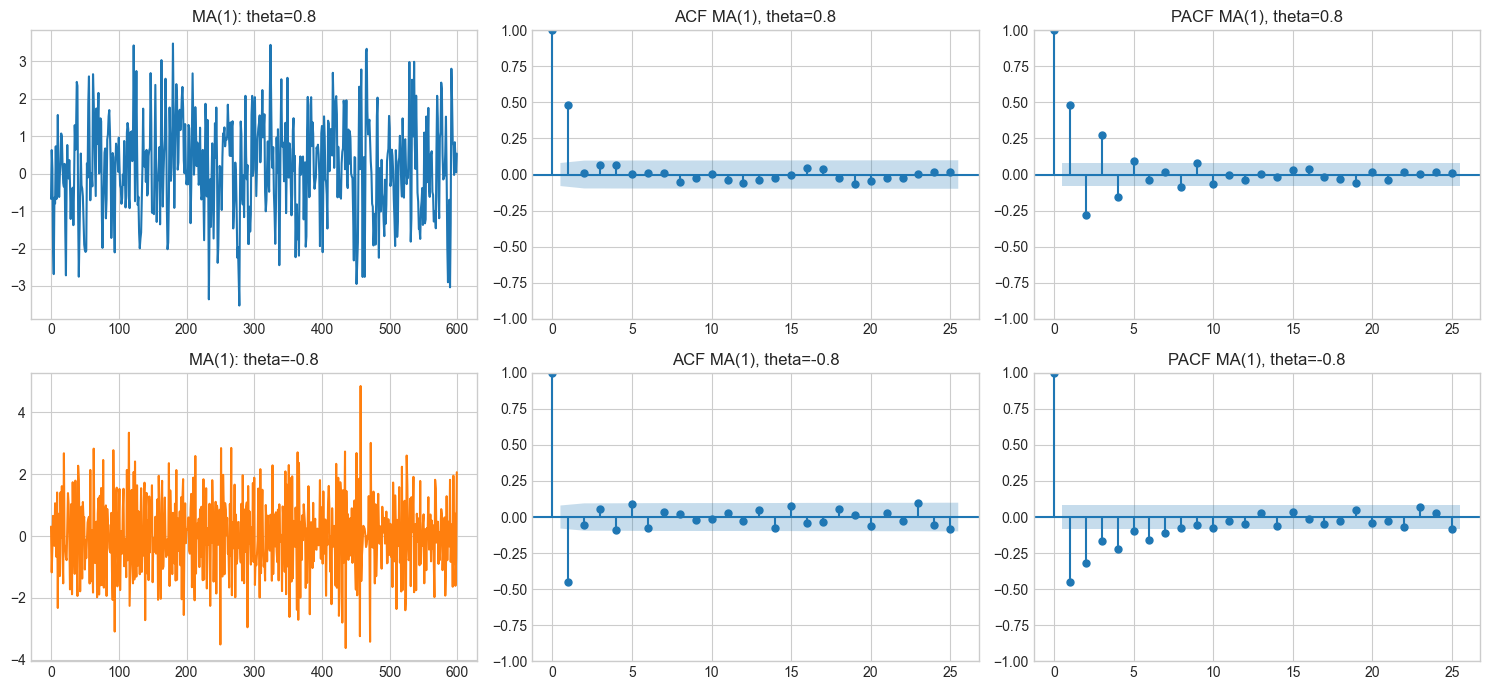

In [44]:
def simulate_arma(ar_params, ma_params, n=600, burnin=200):
    ar = np.r_[1, -np.array(ar_params)]
    ma = np.r_[1, np.array(ma_params)]
    process = ArmaProcess(ar, ma)
    return process.generate_sample(nsample=n, burnin=burnin)

ma1_pos = simulate_arma([], [0.8], n=600)
ma1_neg = simulate_arma([], [-0.8], n=600)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes[0, 0].plot(ma1_pos, color='tab:blue')
axes[0, 0].set_title('MA(1): theta=0.8')
plot_acf(ma1_pos, lags=25, ax=axes[0, 1])
axes[0, 1].set_title('ACF MA(1), theta=0.8')
plot_pacf(ma1_pos, lags=25, method='ywm', ax=axes[0, 2])
axes[0, 2].set_title('PACF MA(1), theta=0.8')

axes[1, 0].plot(ma1_neg, color='tab:orange')
axes[1, 0].set_title('MA(1): theta=-0.8')
plot_acf(ma1_neg, lags=25, ax=axes[1, 1])
axes[1, 1].set_title('ACF MA(1), theta=-0.8')
plot_pacf(ma1_neg, lags=25, method='ywm', ax=axes[1, 2])
axes[1, 2].set_title('PACF MA(1), theta=-0.8')

plt.tight_layout()
plt.show()

### 2.2 Теоретические характеристики MA(1)

Для
$$
Y_t = \varepsilon_t + \theta \varepsilon_{t-1}
$$
имеем:

$$
\mathbb{E}(Y_t)=0, \qquad Var(Y_t)=(1+\theta^2)\sigma^2,
$$

$$
\gamma_1 = \theta \sigma^2, \qquad \gamma_k = 0 \ (k>1),
$$

$$
\rho_1 = \frac{\theta}{1+\theta^2}, \qquad \rho_k=0 \ (k>1).
$$

Интуиция:
- ACF «обрывается» после первого лага,
- знак $\theta$ задает знак первой автокорреляции.


In [45]:
def ma1_rho1(theta):
    return theta / (1 + theta**2)

for th in [0.8, -0.8, 0.5, 2.0]:
    print(f'theta={th:>4}: theoretical rho1={ma1_rho1(th): .3f}')

theta= 0.8: theoretical rho1= 0.488
theta=-0.8: theoretical rho1=-0.488
theta= 0.5: theoretical rho1= 0.400
theta= 2.0: theoretical rho1= 0.400


### 2.3 MA(2) и глубина памяти

Для MA(2) автокорреляция отлична от нуля в основном на лагах 1 и 2, а дальше стремится к 0.

Это и есть смысл параметра $q$: «длина статистической памяти» по шокам.


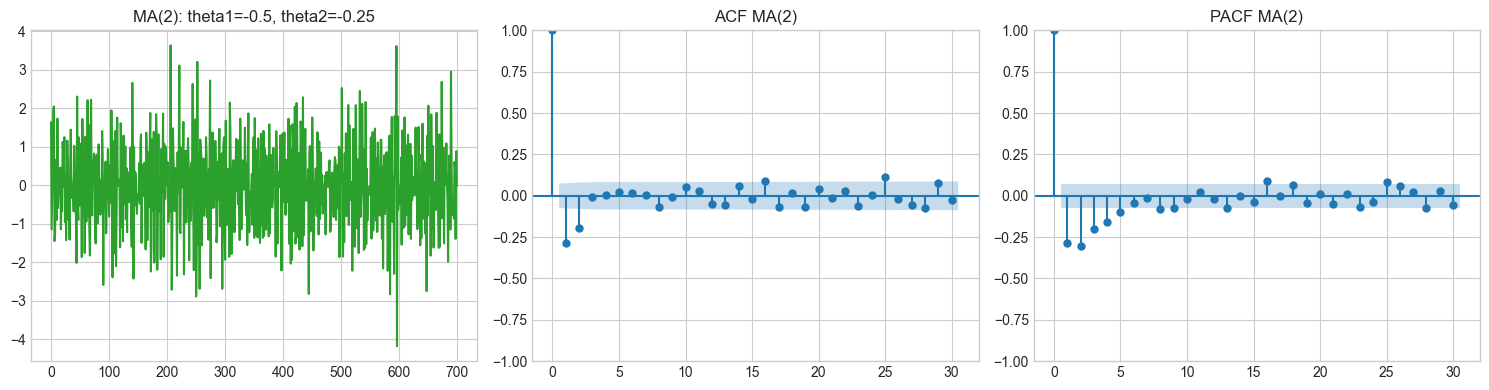

In [46]:
ma2 = simulate_arma([], [-0.5, -0.25], n=700)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ma2, color='tab:green')
axes[0].set_title('MA(2): theta1=-0.5, theta2=-0.25')
plot_acf(ma2, lags=30, ax=axes[1])
axes[1].set_title('ACF MA(2)')
plot_pacf(ma2, lags=30, method='ywm', ax=axes[2])
axes[2].set_title('PACF MA(2)')
plt.tight_layout()
plt.show()

### 2.4 Обратимость MA(q)

Обратимость означает, что MA(q) можно единственно переписать как AR($\\infty$):

$$
Y_t = \\theta(L)\\varepsilon_t, \\quad \\varepsilon_t = \\theta(L)^{-1}Y_t.
$$

Условие: все корни полинома $\\theta(z)=0$ лежат вне единичного круга.

Почему это важно:
- без обратимости MA-представление неединственно,
- возникают проблемы идентификации параметров.


In [47]:
# Для MA(1): 1 + theta*L = 0 -> L = -1/theta
for th in [0.5, 2.0, -0.8, 1.2]:
    root = -1 / th
    print(f'theta={th:>4}: root={root: .3f}, |root|={abs(root):.3f}, invertible={abs(root)>1}')

print()
print('Пара theta=0.5 и theta=2.0 дает одинаковую rho1=0.4, но только |theta|<1 обычно берут как инвертируемое представление.')


theta= 0.5: root=-2.000, |root|=2.000, invertible=True
theta= 2.0: root=-0.500, |root|=0.500, invertible=False
theta=-0.8: root= 1.250, |root|=1.250, invertible=True
theta= 1.2: root=-0.833, |root|=0.833, invertible=False

Пара theta=0.5 и theta=2.0 дает одинаковую rho1=0.4, но только |theta|<1 обычно берут как инвертируемое представление.


Промежуточный вывод по MA: стационарность есть всегда, но для корректной идентификации нужна обратимость.

## 3. AR(p): авторегрессия

### 3.1 Формула и смысл

$$
Y_t = \\alpha_0 + \\alpha_1 Y_{t-1} + \\alpha_2 Y_{t-2} + \\dots + \\alpha_p Y_{t-p} + \\varepsilon_t.
$$

Операторная форма:

$$
\\alpha(L)Y_t = \\alpha_0 + \\varepsilon_t, \\quad \\alpha(L)=1-\\alpha_1L-\\dots-\\alpha_pL^p.
$$

Интуиция: текущее значение напрямую «тянется» из прошлых значений ряда.


### 3.2 Условие стационарности AR(p)

AR(p) стационарен тогда и только тогда, когда все корни уравнения

$$
\\alpha(z)=0
$$

лежат вне единичного круга: $|z_i|>1$.

Если условие выполнено, AR(p) можно представить как MA($\\infty$).


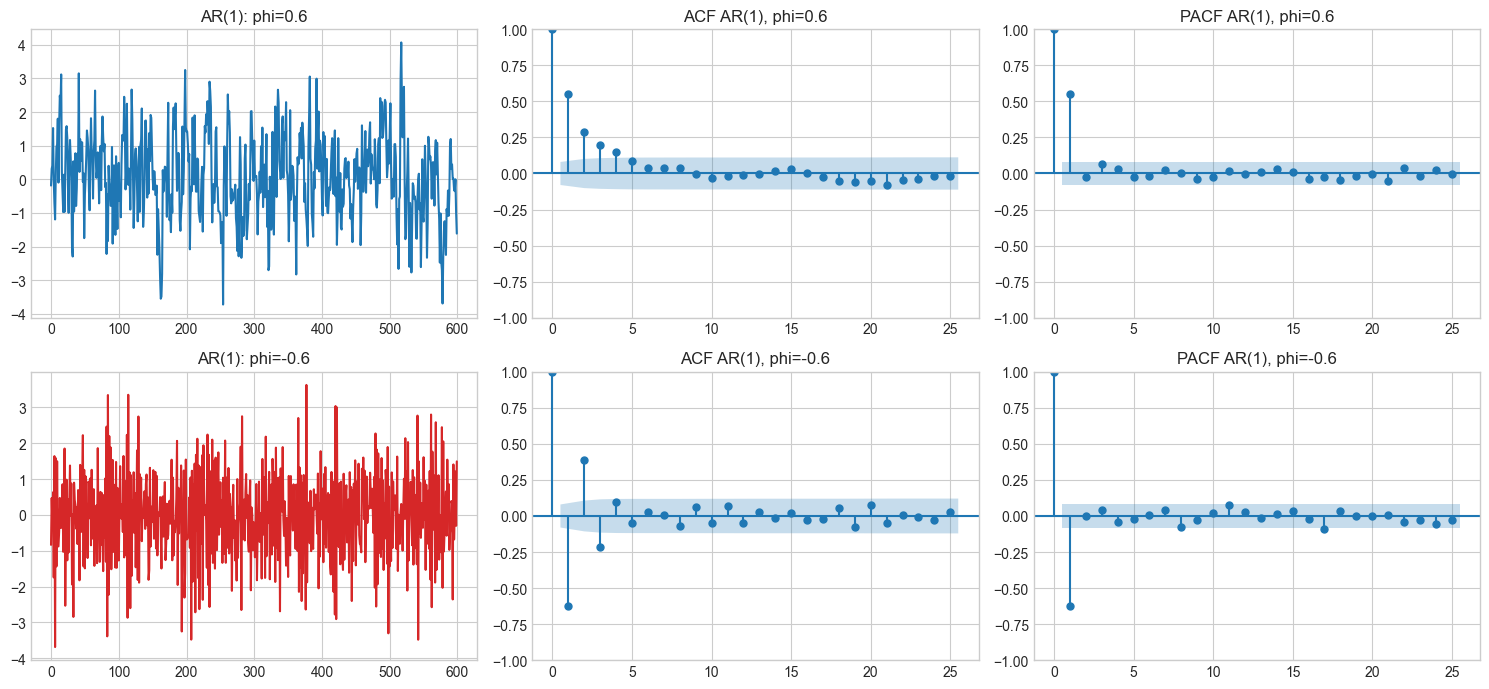

In [48]:
ar1_pos = simulate_arma([0.6], [], n=600)
ar1_neg = simulate_arma([-0.6], [], n=600)

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes[0, 0].plot(ar1_pos, color='tab:blue')
axes[0, 0].set_title('AR(1): phi=0.6')
plot_acf(ar1_pos, lags=25, ax=axes[0, 1])
axes[0, 1].set_title('ACF AR(1), phi=0.6')
plot_pacf(ar1_pos, lags=25, method='ywm', ax=axes[0, 2])
axes[0, 2].set_title('PACF AR(1), phi=0.6')

axes[1, 0].plot(ar1_neg, color='tab:red')
axes[1, 0].set_title('AR(1): phi=-0.6')
plot_acf(ar1_neg, lags=25, ax=axes[1, 1])
axes[1, 1].set_title('ACF AR(1), phi=-0.6')
plot_pacf(ar1_neg, lags=25, method='ywm', ax=axes[1, 2])
axes[1, 2].set_title('PACF AR(1), phi=-0.6')

plt.tight_layout()
plt.show()

Паттерн AR(1):
- ACF убывает постепенно (часто экспоненциально),
- PACF имеет выраженный пик на лаге 1.


### 3.3 AR(2): цикличность и условия

Пример (как в лекции):

$$
Y_t = 1 + 1.3Y_{t-1} - 0.4Y_{t-2} + \\varepsilon_t.
$$

Такие коэффициенты часто дают колебательную динамику с затуханием.


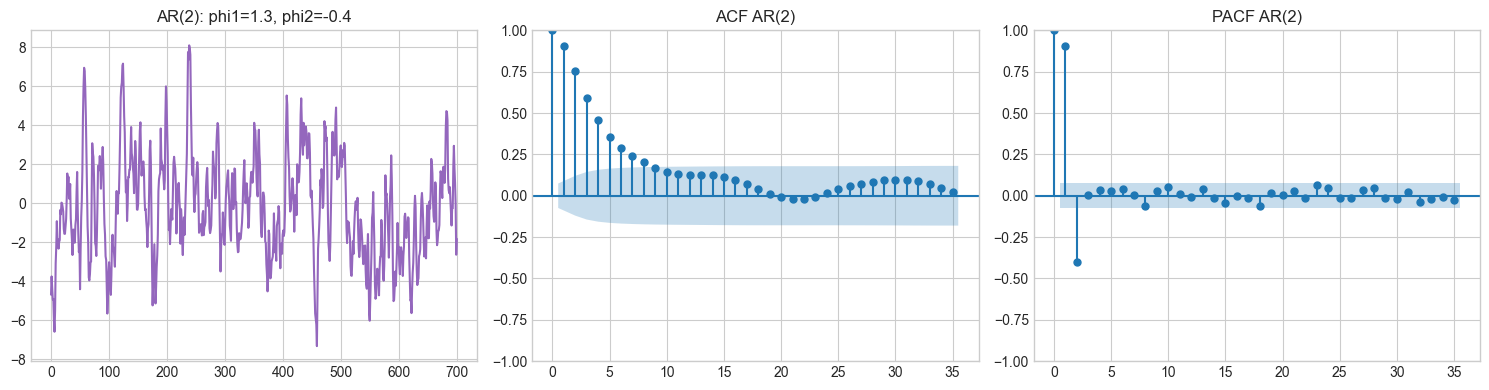

In [49]:
ar2 = simulate_arma([1.3, -0.4], [], n=700)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ar2, color='tab:purple')
axes[0].set_title('AR(2): phi1=1.3, phi2=-0.4')
plot_acf(ar2, lags=35, ax=axes[1])
axes[1].set_title('ACF AR(2)')
plot_pacf(ar2, lags=35, method='ywm', ax=axes[2])
axes[2].set_title('PACF AR(2)')
plt.tight_layout()
plt.show()

In [50]:
# Проверка корней AR-полинома: 1 - 1.3 z + 0.4 z^2 = 0
roots_ar2 = np.roots([0.4, -1.3, 1.0])
print('AR(2) roots:', roots_ar2)
print('moduli:', np.abs(roots_ar2))
print('stationary:', np.all(np.abs(roots_ar2) > 1))

AR(2) roots: [2.   1.25]
moduli: [2.   1.25]
stationary: True


### 3.4 Yule-Walker: связь автокорреляций и параметров

Для стационарного AR(1):

$$
Y_t = \\alpha Y_{t-1} + \\varepsilon_t \\quad \\Rightarrow \\quad \\rho_k = \\alpha^k.
$$

Для AR(2):

$$
\\rho_k = \\alpha_1 \\rho_{k-1} + \\alpha_2 \\rho_{k-2}, \\quad k\\ge 2.
$$

Интуиция: Yule-Walker связывает форму ACF/PACF с параметрами AR и позволяет идентификацию порядка.


Промежуточный вывод по AR: у AR-процессов «длиннее хвост ACF», а ключевая структура проявляется в PACF.

## 4. ARMA(p,q): объединение AR и MA

Общий вид:

$$
Y_t = \\alpha_0 + \\sum_{i=1}^{p} \\alpha_i Y_{t-i} + \\varepsilon_t + \\sum_{j=1}^{q} \\theta_j \\varepsilon_{t-j}.
$$

Операторная форма:

$$
\\alpha(L)Y_t = \\alpha_0 + \\theta(L)\\varepsilon_t.
$$

Интуиция:
- AR-часть отвечает за инерцию ряда,
- MA-часть отвечает за перенос прошлых шоков,
- вместе модель более гибко описывает реальную динамику.


### 4.1 Условия для ARMA(p,q)

- Стационарность: корни $\\alpha(z)=0$ вне единичного круга.
- Обратимость: корни $\\theta(z)=0$ вне единичного круга.

Частные случаи:
- ARMA(p,0)=AR(p),
- ARMA(0,q)=MA(q).


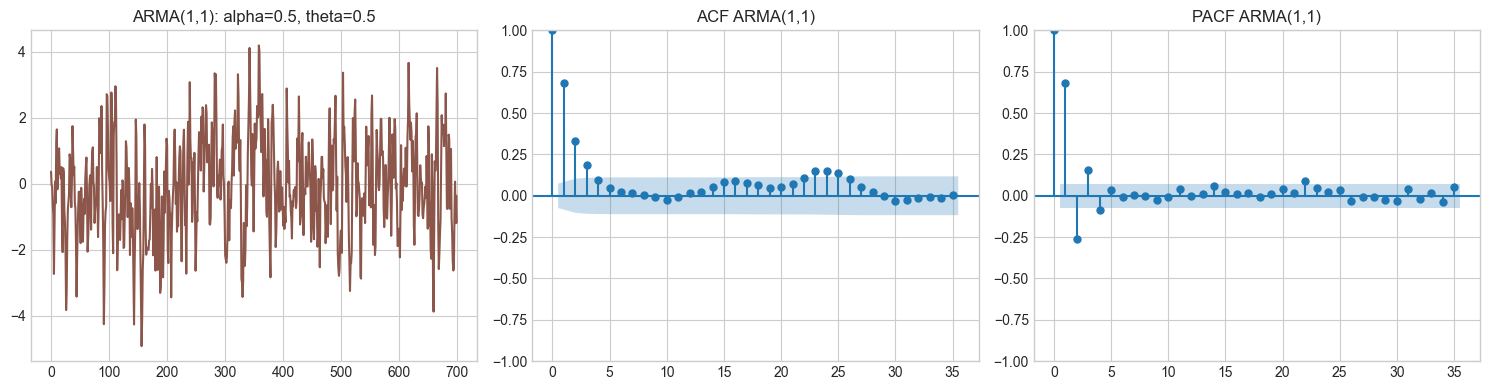

In [51]:
arma11 = simulate_arma([0.5], [0.5], n=700)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(arma11, color='tab:brown')
axes[0].set_title('ARMA(1,1): alpha=0.5, theta=0.5')
plot_acf(arma11, lags=35, ax=axes[1])
axes[1].set_title('ACF ARMA(1,1)')
plot_pacf(arma11, lags=35, method='ywm', ax=axes[2])
axes[2].set_title('PACF ARMA(1,1)')
plt.tight_layout()
plt.show()

In [52]:
# Пример из лекции: ARMA(2,1)
# y_t = 2 + 1.3 y_{t-1} - 0.4 y_{t-2} + e_t - 0.5 e_{t-1}
# AR полином: 1 - 1.3L + 0.4L^2, MA полином: 1 - 0.5L

ar_roots = np.roots([0.4, -1.3, 1.0])
ma_roots = np.roots([-0.5, 1.0])

print('AR roots:', ar_roots, '| moduli:', np.abs(ar_roots), '| stationary:', np.all(np.abs(ar_roots)>1))
print('MA roots:', ma_roots, '| moduli:', np.abs(ma_roots), '| invertible:', np.all(np.abs(ma_roots)>1))

AR roots: [2.   1.25] | moduli: [2.   1.25] | stationary: True
MA roots: [2.] | moduli: [2.] | invertible: True


Типичный практический паттерн ARMA: и ACF, и PACF обычно убывают постепенно, без четкого «обрыва» как у чистых AR или MA.

## 5. Прогнозирование в стационарных моделях

Условный прогноз на $h$ шагов:

$$
\\hat{Y}_{T+h|T} = \\bbE(Y_{T+h} \\mid I_T),
$$

где $I_T$ — информационное множество на момент $T$.

Ошибка прогноза:

$$
e_{T+h|T} = Y_{T+h} - \\hat{Y}_{T+h|T}.
$$

95% доверительный интервал (при нормальности ошибок):

$$
\\hat{Y}_{T+h|T} \\pm 1.96 \\cdot \\hat{\\sigma}_h.
$$

Интуиция:
- с ростом горизонта прогноз обычно тянется к безусловному среднему,
- интервал неопределенности расширяется.


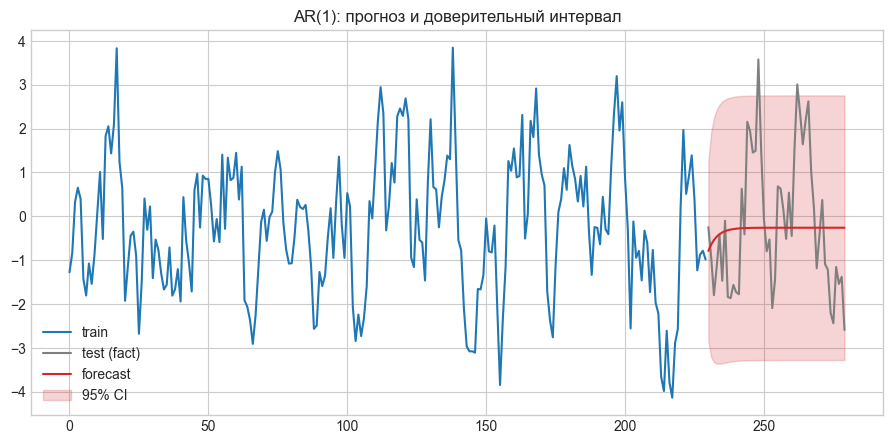

In [53]:
# Прогноз для AR(1)
series_ar = simulate_arma([0.7], [], n=280)
train_ar, test_ar = series_ar[:230], series_ar[230:]

model_ar = ARIMA(train_ar, order=(1, 0, 0)).fit()
fc_ar = model_ar.get_forecast(steps=len(test_ar))
mean_ar = fc_ar.predicted_mean
ci_ar = fc_ar.conf_int(alpha=0.05)

x_train = np.arange(len(train_ar))
x_test = np.arange(len(train_ar), len(train_ar)+len(test_ar))

plt.figure(figsize=(11, 5))
plt.plot(x_train, train_ar, label='train', color='tab:blue')
plt.plot(x_test, test_ar, label='test (fact)', color='tab:gray')
plt.plot(x_test, mean_ar, label='forecast', color='tab:red')
plt.fill_between(x_test, ci_ar[:,0], ci_ar[:,1], color='tab:red', alpha=0.2, label='95% CI')
plt.title('AR(1): прогноз и доверительный интервал')
plt.legend()
plt.show()

In [54]:
# Прогноз для MA(1): быстрое возвращение к среднему
series_ma = simulate_arma([], [0.6], n=280)
train_ma = series_ma[:230]

model_ma = ARIMA(train_ma, order=(0, 0, 1)).fit()
fc_ma = model_ma.get_forecast(steps=12)
print('MA(1) forecast (12 steps):')
print(np.round(fc_ma.predicted_mean, 3))

MA(1) forecast (12 steps):
[-0.594 -0.066 -0.066 -0.066 -0.066 -0.066 -0.066 -0.066 -0.066 -0.066
 -0.066 -0.066]


Промежуточный вывод: при стационарности дальний прогноз содержит меньше «структуры», чем краткосрочный.

## 6. Реальные данные: пример 1 (Sunspots)

Используем годовой ряд солнечной активности (классический пример в литературе по AR-моделям).

Данные сохранены в файле: `sunspots_yearly.csv`.


In [55]:
sun = pd.read_csv('sunspots_yearly.csv')
print(sun.head())
print('rows:', len(sun))

   year  sunspots
0  1700       5.0
1  1701      11.0
2  1702      16.0
3  1703      23.0
4  1704      36.0
rows: 309


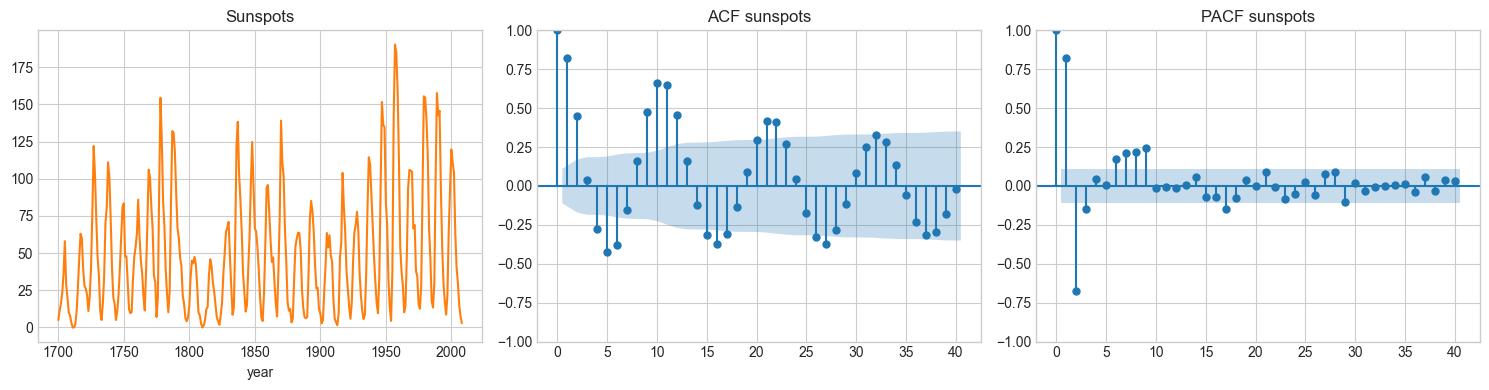

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(sun['year'], sun['sunspots'], color='tab:orange')
axes[0].set_title('Sunspots')
axes[0].set_xlabel('year')
plot_acf(sun['sunspots'], lags=40, ax=axes[1])
axes[1].set_title('ACF sunspots')
plot_pacf(sun['sunspots'], lags=40, method='ywm', ax=axes[2])
axes[2].set_title('PACF sunspots')
plt.tight_layout()
plt.show()

In [57]:
adf_stat, p_value, *_ = adfuller(sun['sunspots'])
print(f'ADF statistic: {adf_stat:.3f}')
print(f'p-value: {p_value:.5f}')

ADF statistic: -2.838
p-value: 0.05308


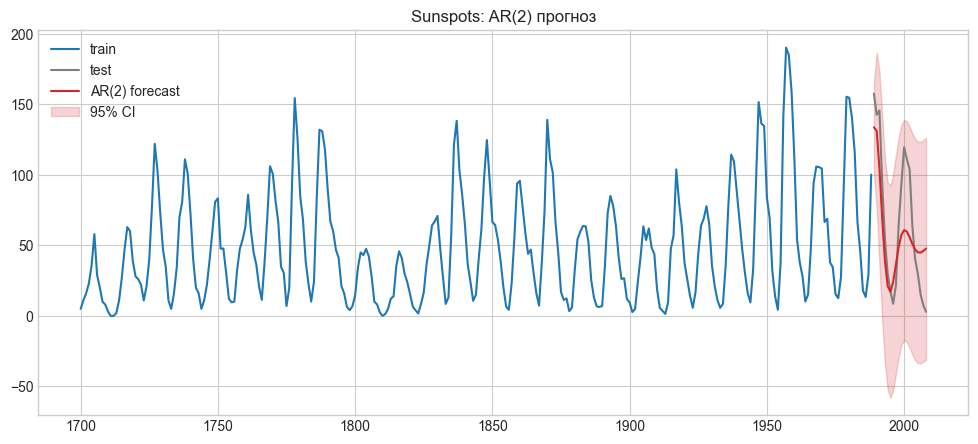

In [58]:
# Оценка AR(2) на sunspots с holdout на последних 20 наблюдениях
vals = sun['sunspots'].values
years = sun['year'].values
train, test = vals[:-20], vals[-20:]
train_years, test_years = years[:-20], years[-20:]

sun_model = ARIMA(train, order=(2, 0, 0)).fit()
sun_fc = sun_model.get_forecast(steps=len(test))
sun_mean = sun_fc.predicted_mean
sun_ci = sun_fc.conf_int(alpha=0.05)

plt.figure(figsize=(12, 5))
plt.plot(train_years, train, label='train', color='tab:blue')
plt.plot(test_years, test, label='test', color='tab:gray')
plt.plot(test_years, sun_mean, label='AR(2) forecast', color='tab:red')
plt.fill_between(test_years, sun_ci[:,0], sun_ci[:,1], color='tab:red', alpha=0.2, label='95% CI')
plt.title('Sunspots: AR(2) прогноз')
plt.legend()
plt.show()

## 7. Реальные данные: пример 2 (Nile)

Добавляем второй реальный ряд: годовой поток Нила (`statsmodels` dataset `nile`).

Данные сохранены в файле: `nile_yearly.csv`.


In [59]:
nile = pd.read_csv('nile_yearly.csv')
print(nile.head())
print('rows:', len(nile))

   year    flow
0  1871  1120.0
1  1872  1160.0
2  1873   963.0
3  1874  1210.0
4  1875  1160.0
rows: 100


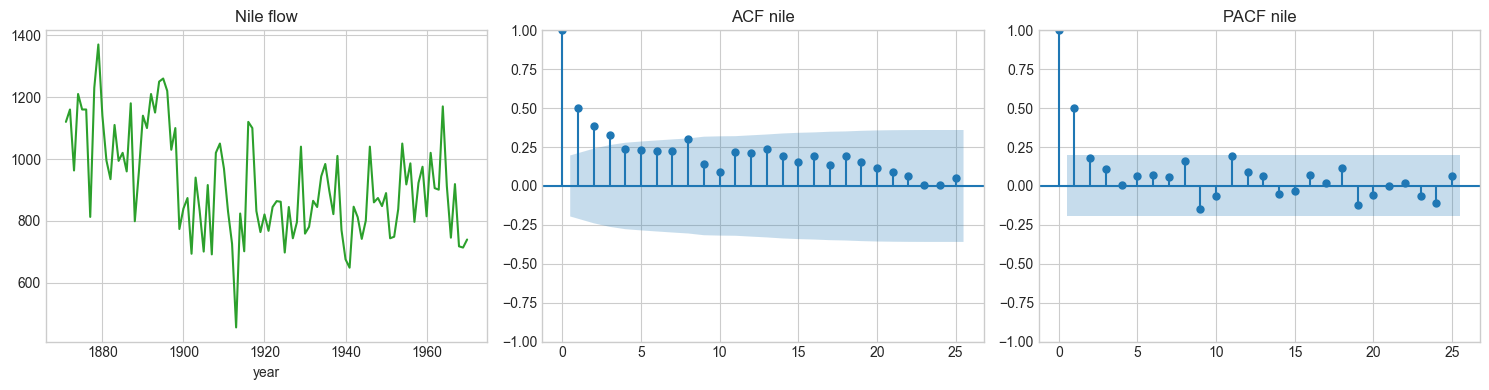

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(nile['year'], nile['flow'], color='tab:green')
axes[0].set_title('Nile flow')
axes[0].set_xlabel('year')
plot_acf(nile['flow'], lags=25, ax=axes[1])
axes[1].set_title('ACF nile')
plot_pacf(nile['flow'], lags=25, method='ywm', ax=axes[2])
axes[2].set_title('PACF nile')
plt.tight_layout()
plt.show()

In [61]:
adf_stat_n, p_value_n, *_ = adfuller(nile['flow'])
print(f'Nile ADF statistic: {adf_stat_n:.3f}')
print(f'Nile p-value: {p_value_n:.5f}')

Nile ADF statistic: -4.049
Nile p-value: 0.00118


In [62]:
# Простой сравнительный пример: AR(1) и MA(1) на Nile
n_vals = nile['flow'].values
n_train, n_test = n_vals[:-15], n_vals[-15:]

n_ar1 = ARIMA(n_train, order=(1, 0, 0)).fit()
n_ma1 = ARIMA(n_train, order=(0, 0, 1)).fit()

fc_ar1 = n_ar1.get_forecast(steps=len(n_test)).predicted_mean
fc_ma1 = n_ma1.get_forecast(steps=len(n_test)).predicted_mean

mae_ar1 = np.mean(np.abs(n_test - fc_ar1))
mae_ma1 = np.mean(np.abs(n_test - fc_ma1))

print(f'Nile holdout MAE AR(1): {mae_ar1:.2f}')
print(f'Nile holdout MAE MA(1): {mae_ma1:.2f}')

Nile holdout MAE AR(1): 102.78
Nile holdout MAE MA(1): 104.35


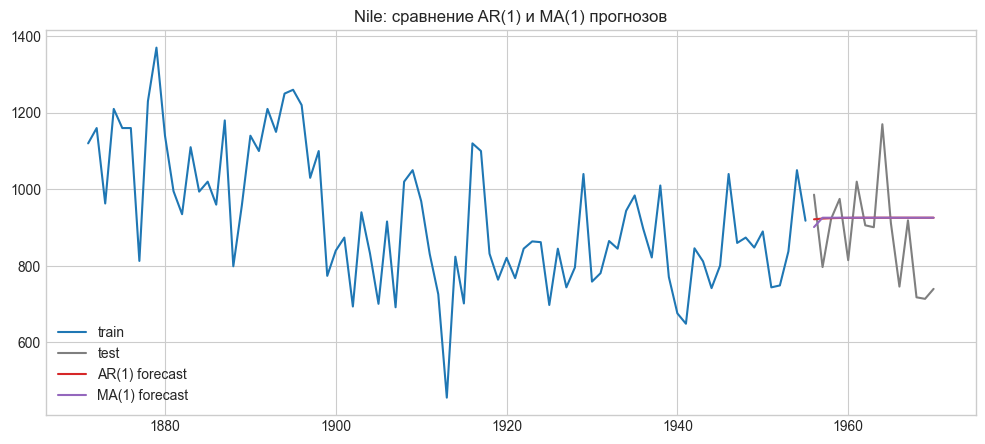

In [63]:
years_test = nile['year'].values[-15:]

plt.figure(figsize=(12, 5))
plt.plot(nile['year'].values[:-15], n_train, label='train', color='tab:blue')
plt.plot(years_test, n_test, label='test', color='tab:gray')
plt.plot(years_test, fc_ar1, label='AR(1) forecast', color='tab:red')
plt.plot(years_test, fc_ma1, label='MA(1) forecast', color='tab:purple')
plt.title('Nile: сравнение AR(1) и MA(1) прогнозов')
plt.legend()
plt.show()

Практический смысл второго примера:
- один и тот же ряд можно разумно аппроксимировать разными стационарными моделями,
- выбор между AR/MA/ARMA — это не только теория ACF/PACF, но и проверка прогнозного качества.


## 8. Тест Льюнга–Бокса и Box–Pierce

В лекции это ключевая проверка значимости автокорреляций остатков.

Гипотеза:
$$
H_0: \rho_1=\rho_2=\dots=\rho_m=0.
$$

Статистика Льюнга–Бокса:
$$
Q_{LB}=T(T+2)\sum_{k=1}^m \frac{\hat{\rho}_k^2}{T-k}.
$$

Интуиция:
- если p-value маленькое, в остатках еще есть структура (модель недообъясняет зависимость),
- если p-value большое, остатки похожи на белый шум.


In [64]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Проверка остатков AR(2) для sunspots
resid_sun = sun_model.resid
lb = acorr_ljungbox(resid_sun, lags=[5, 10, 15], boxpierce=True, return_df=True)
print(lb[['lb_stat','lb_pvalue','bp_stat','bp_pvalue']])


      lb_stat  lb_pvalue    bp_stat  bp_pvalue
5    8.386460   0.136184   8.248299   0.143072
10  29.751125   0.000941  28.779207   0.001353
15  46.056410   0.000052  44.320070   0.000098


Промежуточный вывод: тесты Ljung–Box/Box–Pierce закрывают шаг диагностики в Box–Jenkins и помогают понять, можно ли доверять модели для прогноза.


## 9. Методология Box–Jenkins: полный мини-цикл

Классическая схема:
1. Идентификация (ACF/PACF, стационарность, выбор кандидатов).
2. Оценивание (ARIMA/ARMA с разными $(p,q)$).
3. Диагностика (остатки, Ljung–Box, стабильность параметров).
4. Прогнозирование (точки + интервалы).

Ниже демонстрация на `sunspots`: перебираем небольшую сетку моделей и выбираем по AIC.


In [65]:
# Мини-идентификация: сетка ARMA(p,q), p,q <= 2 (d=0)
candidates = []
for p_ in range(3):
    for q_ in range(3):
        try:
            fit = ARIMA(train, order=(p_, 0, q_)).fit()
            candidates.append((p_, q_, fit.aic, fit.bic))
        except Exception:
            pass

cand_df = pd.DataFrame(candidates, columns=['p','q','AIC','BIC']).sort_values('AIC')
print(cand_df.head(10).to_string(index=False))


 p  q         AIC         BIC
 2  1 2451.480848 2469.812981
 2  0 2452.322128 2466.987834
 2  2 2452.372077 2474.370637
 1  2 2486.326428 2504.658561
 1  1 2534.342914 2549.008621
 0  2 2538.763170 2553.428877
 1  0 2630.665453 2641.664733
 0  1 2692.278510 2703.277790
 0  0 2947.635562 2954.968415


/Users/maria/Desktop/Code/.venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [66]:
# Берем лучшую по AIC и закрываем шаг диагностики
best_p, best_q = cand_df.iloc[0][['p','q']].astype(int)
best_model = ARIMA(train, order=(best_p, 0, best_q)).fit()

diag = acorr_ljungbox(best_model.resid, lags=[10, 15], return_df=True)
print(f'Best model by AIC: ARMA({best_p},{best_q})')
print(diag[['lb_stat','lb_pvalue']])


Best model by AIC: ARMA(2,1)
      lb_stat  lb_pvalue
10  34.727476   0.000139
15  50.711979   0.000009


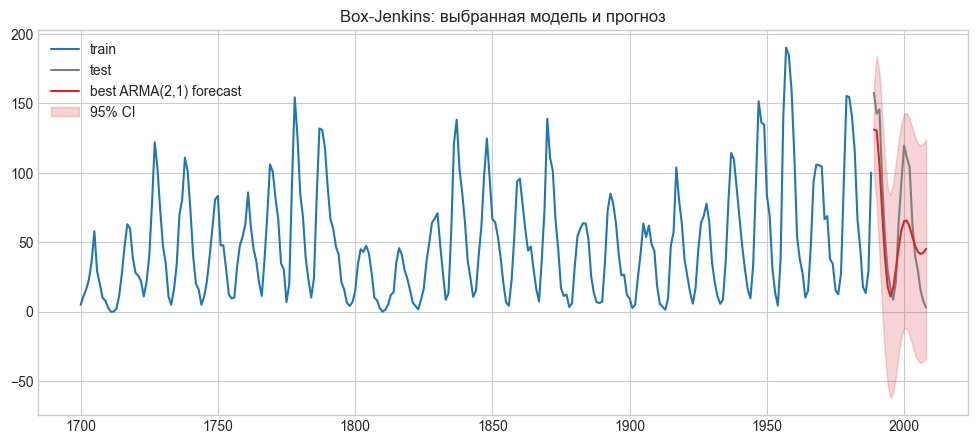

In [67]:
# Шаг прогнозирования для лучшей модели
best_fc = best_model.get_forecast(steps=len(test))
best_mean = best_fc.predicted_mean
best_ci = best_fc.conf_int(alpha=0.05)

plt.figure(figsize=(12,5))
plt.plot(train_years, train, label='train', color='tab:blue')
plt.plot(test_years, test, label='test', color='tab:gray')
plt.plot(test_years, best_mean, label=f'best ARMA({best_p},{best_q}) forecast', color='tab:red')
plt.fill_between(test_years, best_ci[:,0], best_ci[:,1], color='tab:red', alpha=0.2, label='95% CI')
plt.title('Box-Jenkins: выбранная модель и прогноз')
plt.legend()
plt.show()


## 10. Бутстрап-интервалы прогноза

В лекции подчеркивается: если нормальность ошибок сомнительна, интервал можно строить бутстрапом.

Идея:
- берем остатки обученной модели,
- многократно симулируем будущие траектории с ресэмплингом остатков,
- по эмпирическим квантилям получаем prediction interval.


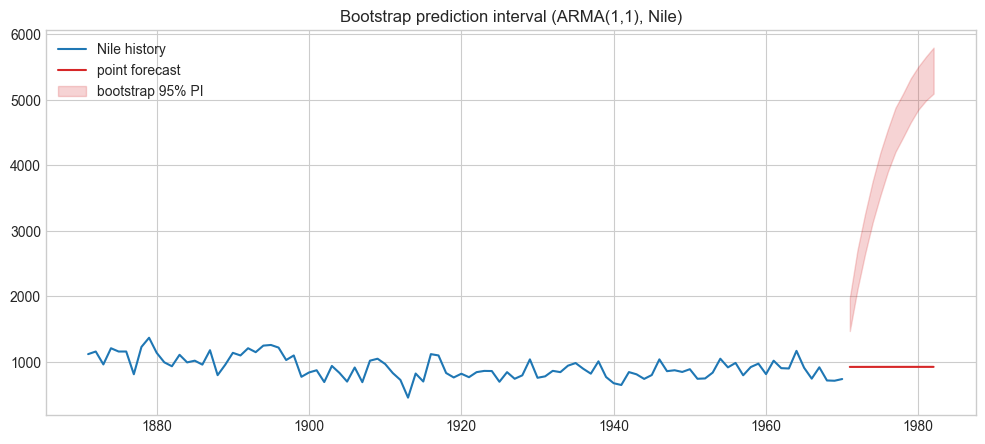

In [68]:
# Бутстрап-интервалы на примере ARMA(1,1), оцененной на Nile
boot_model = ARIMA(n_train, order=(1, 0, 1)).fit()
h = 12
point_fc = boot_model.get_forecast(steps=h).predicted_mean

# Резидуалы и параметры
res = pd.Series(boot_model.resid).dropna().values
const = boot_model.params[0] if 'const' in boot_model.param_names else 0.0
phi = boot_model.arparams[0] if len(boot_model.arparams) else 0.0
theta = boot_model.maparams[0] if len(boot_model.maparams) else 0.0

y_last = float(n_train[-1])
eps_last = float(res[-1])

B = 1000
paths = np.zeros((B, h))
rng = np.random.default_rng(2026)

for b in range(B):
    y_prev = y_last
    e_prev = eps_last
    for t in range(h):
        e_t = rng.choice(res)
        y_t = const + phi * y_prev + e_t + theta * e_prev
        paths[b, t] = y_t
        y_prev, e_prev = y_t, e_t

low = np.percentile(paths, 2.5, axis=0)
high = np.percentile(paths, 97.5, axis=0)

future_years = np.arange(int(nile['year'].iloc[-1]) + 1, int(nile['year'].iloc[-1]) + h + 1)

plt.figure(figsize=(12,5))
plt.plot(nile['year'], nile['flow'], label='Nile history', color='tab:blue')
plt.plot(future_years, point_fc, label='point forecast', color='tab:red')
plt.fill_between(future_years, low, high, color='tab:red', alpha=0.2, label='bootstrap 95% PI')
plt.title('Bootstrap prediction interval (ARMA(1,1), Nile)')
plt.legend()
plt.show()


Промежуточный вывод: бутстрап полезен, когда форма распределения ошибок далека от нормальной, а нам нужен эмпирически устойчивый интервал.


## 11. IRF (Impulse Response Function) для ARMA

IRF — это реакция процесса на единичный шок: последовательность коэффициентов в MA($\infty$)-представлении
$$
Y_t = \mu + \sum_{j=0}^{\infty} \psi_j \varepsilon_{t-j}.
$$

Здесь $\psi_j$ показывает, как шок в момент $t$ влияет на $Y_{t+j}$.

Интуиция:
- у MA(q) IRF обрывается после $q$,
- у стационарного AR(p) IRF затухает постепенно,
- у ARMA эффект обычно затухает, но не обрывается сразу.


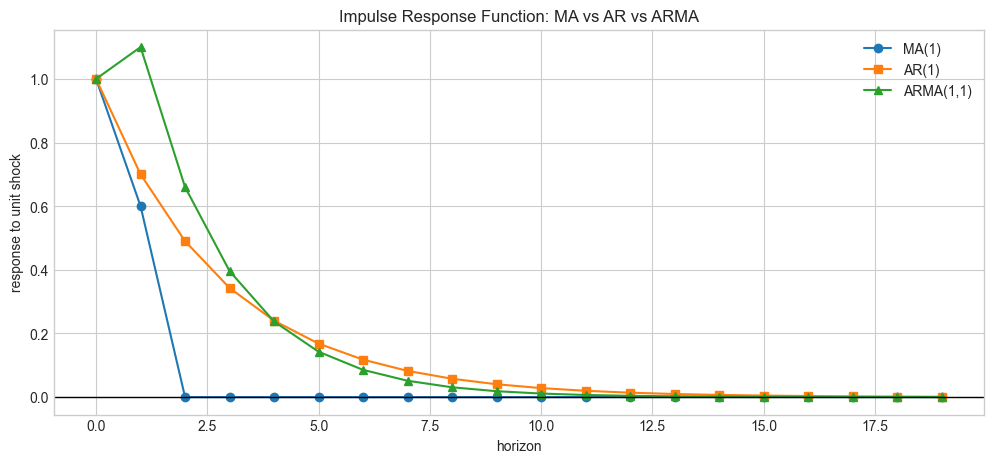

In [69]:
# Сравним IRF для MA(1), AR(1), ARMA(1,1)
h = 20
proc_ma = ArmaProcess(ar=[1], ma=[1, 0.6])
proc_ar = ArmaProcess(ar=[1, -0.7], ma=[1])
proc_arma = ArmaProcess(ar=[1, -0.6], ma=[1, 0.5])

irf_ma = proc_ma.impulse_response(leads=h)
irf_ar = proc_ar.impulse_response(leads=h)
irf_arma = proc_arma.impulse_response(leads=h)

lags = np.arange(h)
plt.figure(figsize=(12,5))
plt.plot(lags, irf_ma, 'o-', label='MA(1)')
plt.plot(lags, irf_ar, 's-', label='AR(1)')
plt.plot(lags, irf_arma, '^-', label='ARMA(1,1)')
plt.axhline(0, color='black', linewidth=1)
plt.title('Impulse Response Function: MA vs AR vs ARMA')
plt.xlabel('horizon')
plt.ylabel('response to unit shock')
plt.legend()
plt.show()


Промежуточный вывод: IRF дает интерпретацию динамики шока во времени и связывает параметры модели с экономическим смыслом реакции системы.


## Мини-итог

1. MA(q): всегда стационарен; ACF обрывается после $q$.
2. AR(p): стационарность через корни AR-полинома; PACF часто обрывается после $p$.
3. ARMA(p,q): сочетает инерцию уровня (AR) и перенос шоков (MA).
4. Обратимость MA-части нужна для уникальности представления.
5. Прогноз на больших горизонтах стремится к среднему, а интервалы расширяются.


## Вопросы для самопроверки

1. Почему MA(1) с $\\theta=0.5$ и $\\theta=2$ может иметь одинаковую $\\rho_1$?
2. Чем логически отличаются условия стационарности AR и обратимости MA?
3. Как по ACF/PACF отличить AR(2), MA(2) и ARMA(1,1) на уровне эвристики?
4. Почему при росте горизонта прогноз ARMA тяготеет к безусловному среднему?
5. Почему в Box-Jenkins после оценки коэффициентов обязательно нужна диагностика остатков?
